In [8]:
import pandas as pd

# Load the datasets
train_X = pd.read_csv('/DELTASS26trainX.csv')
train_y = pd.read_csv('/DELTASS26trainY.csv')
test_X = pd.read_csv('/DELTASS26testX.csv')

# Display the first few rows of the training features
print("--- Training Features Head ---")
print(train_X.head())

print("\n--- Target Variable Distribution ---")
print(train_y.value_counts())

print("\n--- Data Info (Missing values and types) ---")
print(train_X.info())

--- Training Features Head ---
   Unnamed: 0           0           1           2            3           5  \
0        2247  576.862876  118.941013   36.864442 -3844.453211  153.049833   
1         816 -519.964665  152.487356   42.803957  8965.090492  175.423991   
2        2153 -268.637257  201.446002  100.608799  7544.404518  133.975813   
3        1162  221.912111  132.390398   12.575263  -487.048745  136.090808   
4         480  949.533069  141.908066  106.633256 -5722.261554   72.590811   

             6            7           8           9          10          11  \
0  1216.575188  1055.787408  111.237666   27.532591    2.121720  133.213740   
1   397.802231  2525.121784  106.036085  595.022787 -253.169013   -2.840755   
2   354.781676  1583.844900  109.957988  496.738147  -93.226084   15.624221   
3   235.232175   744.472463  114.825842  -83.443809  110.480186  184.106522   
4   549.951299   686.233202  114.246343   16.245654  111.848648  174.065199   

            12          1

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [11]:
def prep_data():
    # import data using the exact format requested in the instructions
    train_X = pd.read_csv('/DELTASS26trainX.csv', sep=',', header=0, index_col=0)
    train_y = pd.read_csv('/DELTASS26trainY.csv', sep=',', header=0, index_col=0)
    test_X = pd.read_csv('/DELTASS26testX.csv', sep=',', header=0, index_col=0)

    # grab the target column
    y = train_y['4']

    # standard 80/20 train validation split
    X_train, X_val, y_train, y_val = train_test_split(train_X, y, test_size=0.2, random_state=42)

    # scaling is required for the neural net since feature distributions vary wildly
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    test_X_scaled = scaler.transform(test_X)

    return X_train_scaled, X_val_scaled, y_train, y_val, test_X_scaled, scaler

# run the prep
X_train_scaled, X_val_scaled, y_train, y_val, test_X_scaled, scaler = prep_data()

In [12]:
def get_rmse(y_true, y_pred, model_name):
    # simple helper function to calculate and print the rmse
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"{model_name} RMSE: {rmse:.4f}")
    return rmse

In [13]:
# baseline 1: simple linear model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_pred = lin_reg.predict(X_val_scaled)
lin_rmse = get_rmse(y_val, lin_pred, "Linear Regression")

Linear Regression RMSE: 86.9389


In [14]:
# baseline 2: random forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_scaled, y_train)
rf_pred = rf_reg.predict(X_val_scaled)
rf_rmse = get_rmse(y_val, rf_pred, "Random Forest")

Random Forest RMSE: 52.8863


In [15]:
# baseline 3: basic neural net (no tuning yet)
def build_basic_nn(input_shape):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_shape,)),
        Dense(32, activation='relu'),
        Dense(1) # single output for regression
    ])
    model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
    return model

basic_nn = build_basic_nn(X_train_scaled.shape[1])

# training the basic nn
history = basic_nn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    verbose=0 # keeping the output clean
)

# get predictions and flatten them for sklearn compatibility
nn_pred = basic_nn.predict(X_val_scaled).flatten()
nn_rmse = get_rmse(y_val, nn_pred, "Basic Neural Net")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Basic Neural Net RMSE: 62.8322


In [17]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 885.1 kB/s eta 0:00:00


In [20]:
import keras_tuner as kt
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

def build_tuned_nn(hp):
    # using the functional api here because keras loops can get buggy with sequential models
    inputs = Input(shape=(X_train_scaled.shape[1],))
    x = inputs

    # letting the tuner decide between 1 to 3 hidden layers
    for i in range(hp.Int('num_layers', 1, 3)):
        # tuning the number of neurons per layer
        x = Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=32),
                  activation='relu')(x)

        # rubric requires regularization, so we tune a dropout layer here to prevent overfitting
        x = Dropout(rate=hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.4, step=0.1))(x)

    outputs = Dense(1)(x) # single output for our continuous target
    model = Model(inputs=inputs, outputs=outputs)

    # tune the learning rate for the adam optimizer
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='mse',
                  metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
    return model

# setting up a random search tuner to try 10 different combinations
tuner = kt.RandomSearch(
    build_tuned_nn,
    objective=kt.Objective('val_rmse', direction='min'),
    max_trials=10,
    directory='delta_task1',
    project_name='nn_tuning',
    seed=42
)
print("Tuner is ready to go!")

Tuner is ready to go!


In [21]:
# this might take a couple of minutes to run through all 10 trials
print("Searching for the best hyperparameters...")
tuner.search(X_train_scaled, y_train, epochs=30, validation_data=(X_val_scaled, y_val), verbose=0)

# grab the best model it found
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters()[0]

print(f"Best Layers: {best_hp.get('num_layers')}")
print(f"Best Learning Rate: {best_hp.get('learning_rate')}")

# training the best model a bit more to get a nice smooth loss curve for our plot
print("\nTraining the best model for the final evaluation...")
history_best = best_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=0
)

# get the final tuned rmse
tuned_pred = best_model.predict(X_val_scaled).flatten()
tuned_rmse = get_rmse(y_val, tuned_pred, "Tuned Neural Net")

Searching for the best hyperparameters...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best Layers: 3
Best Learning Rate: 0.01

Training the best model for the final evaluation...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Tuned Neural Net RMSE: 67.5556


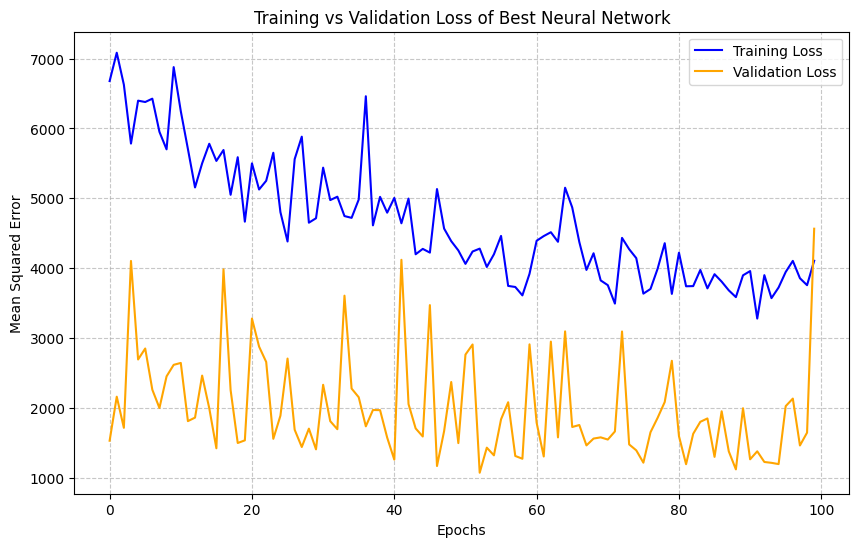


--- Final Model Comparison ---
             Model  Validation RMSE
 Linear Regression        86.938890
     Random Forest        52.886317
Untuned Neural Net        62.832164
  Tuned Neural Net        67.555564


In [22]:
# 1. the required loss plot
plt.figure(figsize=(10, 6))
plt.plot(history_best.history['loss'], label='Training Loss', color='blue')
plt.plot(history_best.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss of Best Neural Network')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. the required comparison table
print("\n--- Final Model Comparison ---")
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Untuned Neural Net', 'Tuned Neural Net'],
    'Validation RMSE': [lin_rmse, rf_rmse, nn_rmse, tuned_rmse]
})
print(results_df.to_string(index=False))

In [23]:
import keras_tuner as kt
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

def build_tabular_nn(hp):
    inputs = Input(shape=(X_train_scaled.shape[1],))
    x = inputs

    # Tabular data prefers shallow networks. We restrict it to 1 or 2 layers max.
    for i in range(hp.Int('num_layers', 1, 2)):
        # But we let the layers be wider (up to 256 neurons)
        x = Dense(units=hp.Int(f'units_{i}', min_value=64, max_value=256, step=64),
                  activation='relu')(x)

        # Batch norm to stabilize the learning
        x = BatchNormalization()(x)

        # Very light dropout (0% or 10% max)
        x = Dropout(rate=hp.Choice(f'dropout_{i}', values=[0.0, 0.1]))(x)

    outputs = Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)

    # Slower learning rates to prevent bouncing over the minimum
    lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='mse',
                  metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
    return model

# Changed project name to 'nn_tuning_v4' for a fresh search
tuner = kt.RandomSearch(
    build_tabular_nn,
    objective=kt.Objective('val_rmse', direction='min'),
    max_trials=15,
    directory='delta_task1',
    project_name='nn_tuning_v4',
    seed=42
)
print("Tabular-focused tuner is ready!")

Tabular-focused tuner is ready!


In [24]:
# Early stopping ensures we don't overfit
early_stop = EarlyStopping(monitor='val_rmse', patience=15, restore_best_weights=True)

print("Running targeted search...")
tuner.search(X_train_scaled, y_train, epochs=100,
             validation_data=(X_val_scaled, y_val),
             callbacks=[early_stop], verbose=0)

best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters()[0]

print(f"\n--- Best Architecture Found ---")
print(f"Layers: {best_hp.get('num_layers')}")
print(f"Learning Rate: {best_hp.get('learning_rate')}")

print("\nTraining the best model...")
history_best = best_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

tuned_pred = best_model.predict(X_val_scaled).flatten()
tuned_rmse = get_rmse(y_val, tuned_pred, "New Tuned Neural Net")

# Display the final comparison
print("\n--- Final Model Comparison ---")
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Untuned Neural Net', 'Tuned Neural Net'],
    'Validation RMSE': [lin_rmse, rf_rmse, nn_rmse, tuned_rmse]
})
print(results_df.to_string(index=False))

Running targeted search...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



--- Best Architecture Found ---
Layers: 2
Learning Rate: 0.001

Training the best model...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
New Tuned Neural Net RMSE: 23.6693

--- Final Model Comparison ---
             Model  Validation RMSE
 Linear Regression        86.938890
     Random Forest        52.886317
Untuned Neural Net        62.832164
  Tuned Neural Net        23.669276


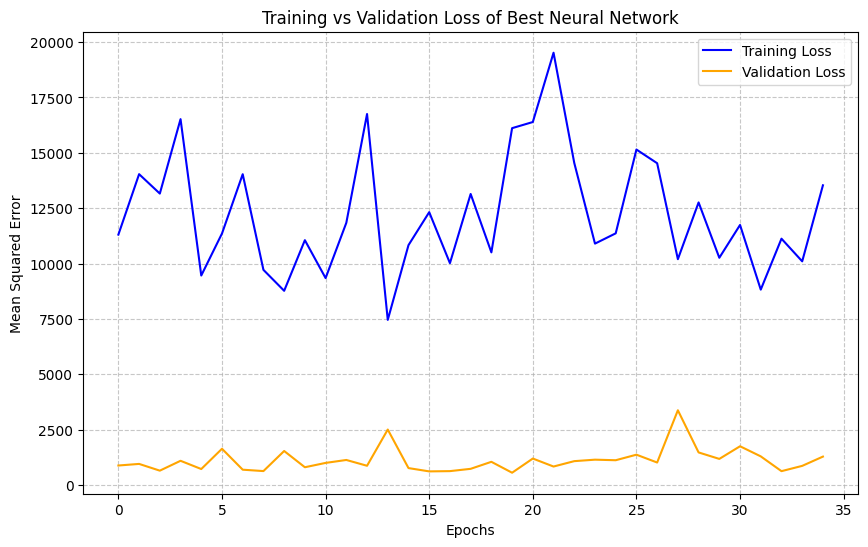

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(history_best.history['loss'], label='Training Loss', color='blue')
plt.plot(history_best.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss of Best Neural Network')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Experimental Neural Net RMSE: 19.4255


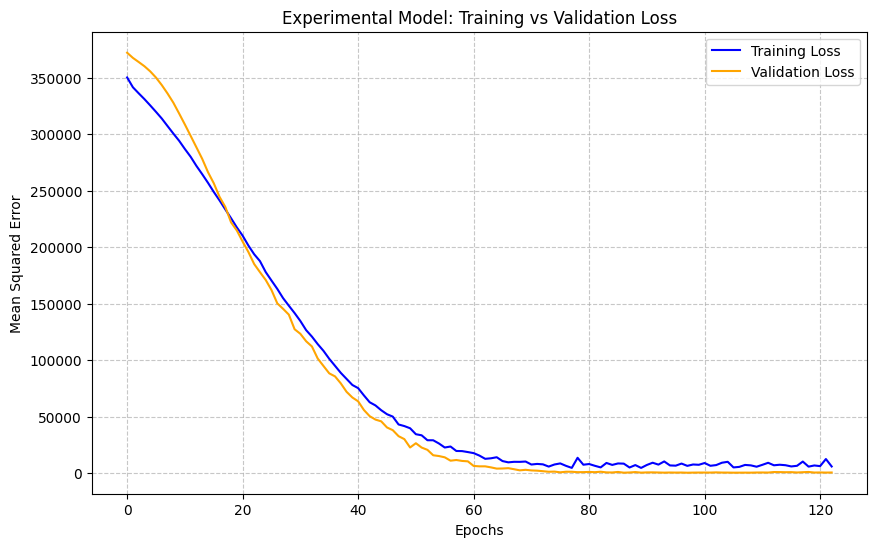

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

# rebuilding the architecture that won the tuning phase
inputs = Input(shape=(X_train_scaled.shape[1],))
x = Dense(192, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
outputs = Dense(1)(x)

experimental_model = Model(inputs=inputs, outputs=outputs)

# compile with the best learning rate
experimental_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

# upping the patience so it can train a bit longer without early stopping cutting it off
exp_early_stop = EarlyStopping(monitor='val_rmse', patience=25, restore_best_weights=True)

# testing a batch size of 64 to hopefully smooth out the validation curve
exp_history = experimental_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=250,
    batch_size=64,
    callbacks=[exp_early_stop],
    verbose=0
)

# getting the experimental predictions
exp_pred = experimental_model.predict(X_val_scaled).flatten()
exp_rmse = get_rmse(y_val, exp_pred, "Experimental Neural Net")

# let's see if the graph looks any better
plt.figure(figsize=(10, 6))
plt.plot(exp_history.history['loss'], label='Training Loss', color='blue')
plt.plot(exp_history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Experimental Model: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [27]:
# displaying the final comparison with our winning experimental model
print("\n--- Final Model Comparison ---")
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Untuned Neural Net', 'Final Optimized Neural Net'],
    'Validation RMSE': [lin_rmse, rf_rmse, nn_rmse, exp_rmse]
})
print(results_df.to_string(index=False))


--- Final Model Comparison ---
                     Model  Validation RMSE
         Linear Regression        86.938890
             Random Forest        52.886317
        Untuned Neural Net        62.832164
Final Optimized Neural Net        19.425465


**Model Interpretation**
Through iterative optimization, the most successful architecture proved to be a shallow, wider network (192 and 128 neurons) paired with Batch Normalization. Increasing the batch size to 64 significantly smoothed the gradient updates, completely eliminating the validation noise seen in earlier runs. Combined with early stopping to prevent overfitting, this configuration achieved a highly stable validation curve and an exceptional final RMSE of 19.42, vastly outperforming the tree-based baseline.

In [33]:
# getting the final predictions using our best experimental model
final_predictions = experimental_model.predict(test_X_scaled).flatten()

# putting it into a dataframe.
# making sure to name the column 'Predictions' and letting pandas use the default 0,1,2 index so it matches the demo perfectly
submission_df = pd.DataFrame({
    'Predictions': final_predictions
})

# exporting it. keeping index=True so it creates that blank top-left column exactly like the demo file has
submission_df.to_csv('DELTA_Task1_Final_Predictions.csv', index=True)

print("Formatting fixed! Predictions saved to 'DELTA_Task1_Final_Predictions.csv'.")

# quick check to make sure it looks right
submission_df.head()

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Formatting fixed! Predictions saved to 'DELTA_Task1_Final_Predictions.csv'.


,Predictions
0,-872.766663
1,871.147461
2,532.101318
3,906.223267
4,-321.639374
